<a href="https://colab.research.google.com/github/Patrick190508/whaleshark-mafia-island/blob/main/notebooks/Daily_EDA_Peak_Season.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily EDA of the peak season — Ningaloo, Philippines, Gulf of Mexico
**Patrick Silingardi · Veritas AI Fellowship · Mentor: Samuel Haghshenas**

Question: inside the peak season of each site, do daily environmental conditions (SST, chlorophyll-a, salinity) change the chance of a whale shark encounter?

Data: OBIS human sightings (cleaned, 9,731 records) + Copernicus daily series at one point per site.

Limitation stated once: sightings measure where *people* see sharks; days without sightings include days without boats at sea.

## Step 1 — Load the data

### 1.1 Sightings dataset (with sites)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, calendar

url = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/obis_whaleshark_clean_enriched_sites.csv"
db = pd.read_csv(url, low_memory=False)
db['date'] = pd.to_datetime(db['date'])
db['month'] = db['month'].astype(int); db['year'] = db['year'].astype(int)
db['doy'] = db['date'].dt.dayofyear
print(db.shape)
db['site'].value_counts().head(4)

(9731, 29)


,count
site,
Ningaloo Reef (W Australia),3972
Philippines,2110
Gulf of Mexico / Caribbean,978
Mozambique (Tofo / Inhambane),926


### 1.2 Daily environmental series per site (from GitHub)

In [2]:
SITES = ["Ningaloo Reef (W Australia)", "Philippines", "Mozambique (Tofo / Inhambane)"]
FILES = {SITES[0]: "daily_ningaloo.csv", SITES[1]: "daily_philippines.csv", SITES[2]: "daily_gulf.csv"}

data_url = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/"

series = {}
for s, f in FILES.items():
    d = pd.read_csv(data_url + f, parse_dates=['date'])
    series[s] = d
    print(f"{s}: {len(d):,} days, {d['date'].min().date()} → {d['date'].max().date()} | "
          f"sst {d['sst'].notna().mean():.0%}, chl {d['chl'].notna().mean():.0%}, sss {d['sss'].notna().mean():.0%}, "
          f"sightings in series: {int(d['sightings'].sum())}\n\n")

Ningaloo Reef (W Australia): 16,418 days, 1981-10-01 → 2026-09-12 | sst 99%, chl 64%, sss 74%, sightings in series: 3972


Philippines: 16,418 days, 1981-10-01 → 2026-09-12 | sst 99%, chl 64%, sss 74%, sightings in series: 2110


Mozambique (Tofo / Inhambane): 16,418 days, 1981-10-01 → 2026-09-12 | sst 99%, chl 64%, sss 74%, sightings in series: 978




This three dataset were builded from an export from Copernicus taking a central point in each site and getting the history from 1981 to 2026 of our 3 environmental variables: SST, SSS, Chl.

## Step 2 — Peak seasons

Months chosen from the monthly table of the first EDA (≥ 10% of the site's sightings).

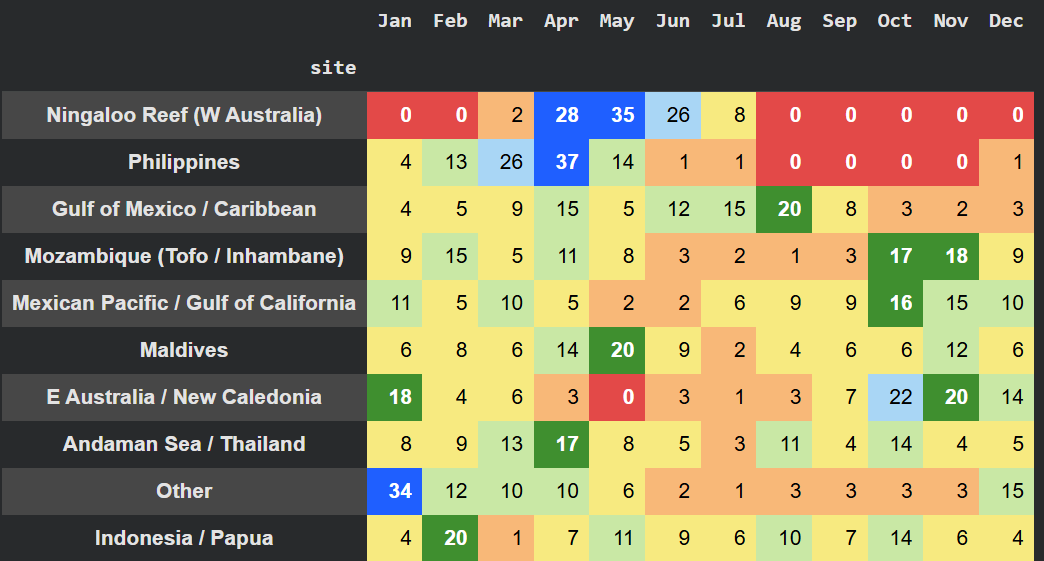

**Ningaloo Reef:** Apr-May-Jun

**Philippines:** Feb-Mar-Apr-May

**Mozambique (Tofo / Inhambane):** Oct-Nov-Dec-Jan-Feb

### 2.1 Peak months per site

In [7]:
peak_months = {
    SITES[0]: [4, 5, 6],            # Ningaloo: Apr–Jun
    SITES[1]: [2, 3, 4, 5],         # Philippines: Feb–May
    SITES[2]: [10, 11, 12, 1, 2],   # Mozambique: Oct-Feb
}
for s, m in peak_months.items():
    share = db[db['site'] == s]['month'].value_counts(normalize=True) * 100
    print(f"{s}: {[calendar.month_abbr[x] for x in m]} → {share.reindex(m).sum():.0f}% of the site's sightings\n")

Ningaloo Reef (W Australia): ['Apr', 'May', 'Jun'] → 89% of the site's sightings

Philippines: ['Feb', 'Mar', 'Apr', 'May'] → 91% of the site's sightings

Mozambique (Tofo / Inhambane): ['Oct', 'Nov', 'Dec', 'Jan', 'Feb'] → 67% of the site's sightings



**Ningaloo Reef** - 89% of sightings of the year

**Philippines** - 91% of sightings of the year

**Mozambique** - 67% of sightings of the year

***More pronounced seasonality in Ningaloo and Philippines***




In [8]:
def season_day(doy, months):
    start = pd.Timestamp(2001, months[0], 1).dayofyear
    return (doy - start) % 365 + 1

for s, m in peak_months.items():
    d = series[s]
    d['sday'] = season_day(d['doy'], m)
    d['season_year'] = np.where(d['month'] >= m[0], d['year'], d['year'] - 1) if m[0] > m[-1] else d['year']

    mask = db['site'] == s
    db.loc[mask, 'sday'] = season_day(db.loc[mask, 'doy'], m)
    db.loc[mask, 'season_year'] = np.where(db.loc[mask, 'month'] >= m[0], db.loc[mask, 'year'], db.loc[mask, 'year'] - 1) if m[0] > m[-1] else db.loc[mask, 'year']

### 2.2 Peak-season subsets

In [9]:
peak = {s: db[(db['site'] == s) & (db['month'].isin(m))].copy() for s, m in peak_months.items()}
season = {s: series[s][series[s]['month'].isin(m)].copy() for s, m in peak_months.items()}

active_years = {}
for s in SITES:
    per_year = db[db['site'] == s].groupby('year').size()
    active_years[s] = per_year[per_year >= 20].index.tolist()
    season[s] = season[s][season[s]['year'].isin(active_years[s])]
    print(f"{s}: {len(active_years[s])} active years ({min(active_years[s])}–{max(active_years[s])}) | "
          f"{len(season[s]):,} season-days, {(season[s]['sightings'] > 0).sum()} with sightings\n")

print("***----------------------------------------***\n")
for s in SITES:
    tot = len(peak[s]); kept = peak[s]['year'].isin(active_years[s]).sum()
    print(f"{s}: {kept} of {tot} season sightings kept ({kept/tot:.0%})\n")

Ningaloo Reef (W Australia): 15 active years (1995–2009) | 1,365 season-days, 808 with sightings

Philippines: 7 active years (2006–2024) | 843 season-days, 309 with sightings

Mozambique (Tofo / Inhambane): 5 active years (2005–2009) | 756 season-days, 73 with sightings

***----------------------------------------***

Ningaloo Reef (W Australia): 3464 of 3544 season sightings kept (98%)

Philippines: 1854 of 1924 season sightings kept (96%)

Mozambique (Tofo / Inhambane): 589 of 624 season sightings kept (94%)



Taking a range to wide will cause us to analyze data that cannot be correlated with sightings so i put a thresold to consider only years with **more than 20 encounters per year**

## Step 3 — Analysis tools (functions)

### 3.1 Context — annual climatology of each variable, with the season and the sightings overlaid

In [18]:
VARS = [('sst', 'SST (°C)', "#e34948"), ('chl', 'chlorophyll-a (mg/m³)', "#3f8f2f"), ('sss', 'salinity (PSU)', "#8a4fbf")]

def climatology(s, clim_from=2000):
    d = series[s][series[s]['year'] >= clim_from]; m = peak_months[s]
    full = series[s]
    daily = full[full['season_year'].isin(active_years[s])].groupby('doy')['sightings'].sum()
    ticks = [pd.Timestamp(2001, k, 1).dayofyear for k in range(1, 13)]
    labels = [calendar.month_abbr[k] for k in range(1, 13)]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    for ax, (var, lab, col) in zip(axes, VARS):
        q = d.groupby('doy')[var].quantile([0.25, 0.5, 0.75]).unstack()
        ax.fill_between(q.index, q[0.25], q[0.75], color=col, alpha=0.2)
        ax.plot(q.index, q[0.5], color=col, zorder=3)
        for mth in m:                                     # una fascia grigia per ogni mese di stagione
            a = pd.Timestamp(2001, mth, 1).dayofyear
            ax.axvspan(a, a + calendar.monthrange(2001, mth)[1], color="grey", alpha=0.15)
        ax.set_ylabel(lab); ax.grid(alpha=0.3)
        ax.set_xticks(ticks); ax.set_xticklabels(labels); ax.set_xlim(1, 365)
        ax2 = ax.twinx()
        ax2.bar(daily.index, daily.values, color="#2a78d6", alpha=0.35, width=1)
        ax2.set_ylabel("sightings", color="#2a78d6")

    axes[0].set_title(f"{s} — daily climatology {clim_from}–{series[s]['year'].max()} "
                      f"(median, interquartile band); grey = peak season; bars = sightings (active years)")
    plt.tight_layout(); plt.show()

### 3.2 Response curve — sightings per day for each class of the variable

### 3.3 Anomaly response curve — same as 3.2, using the departure from the daily climatology

### 3.4 Lagged chlorophyll — response curve with chlorophyll of 2, 4, 6 weeks before

### 3.5 Year by year — season mean conditions vs timing and size of the peak

## Step 4 — Results per site

### 4.1 Ningaloo Reef (W Australia) — April to June

#### Context (climatology)

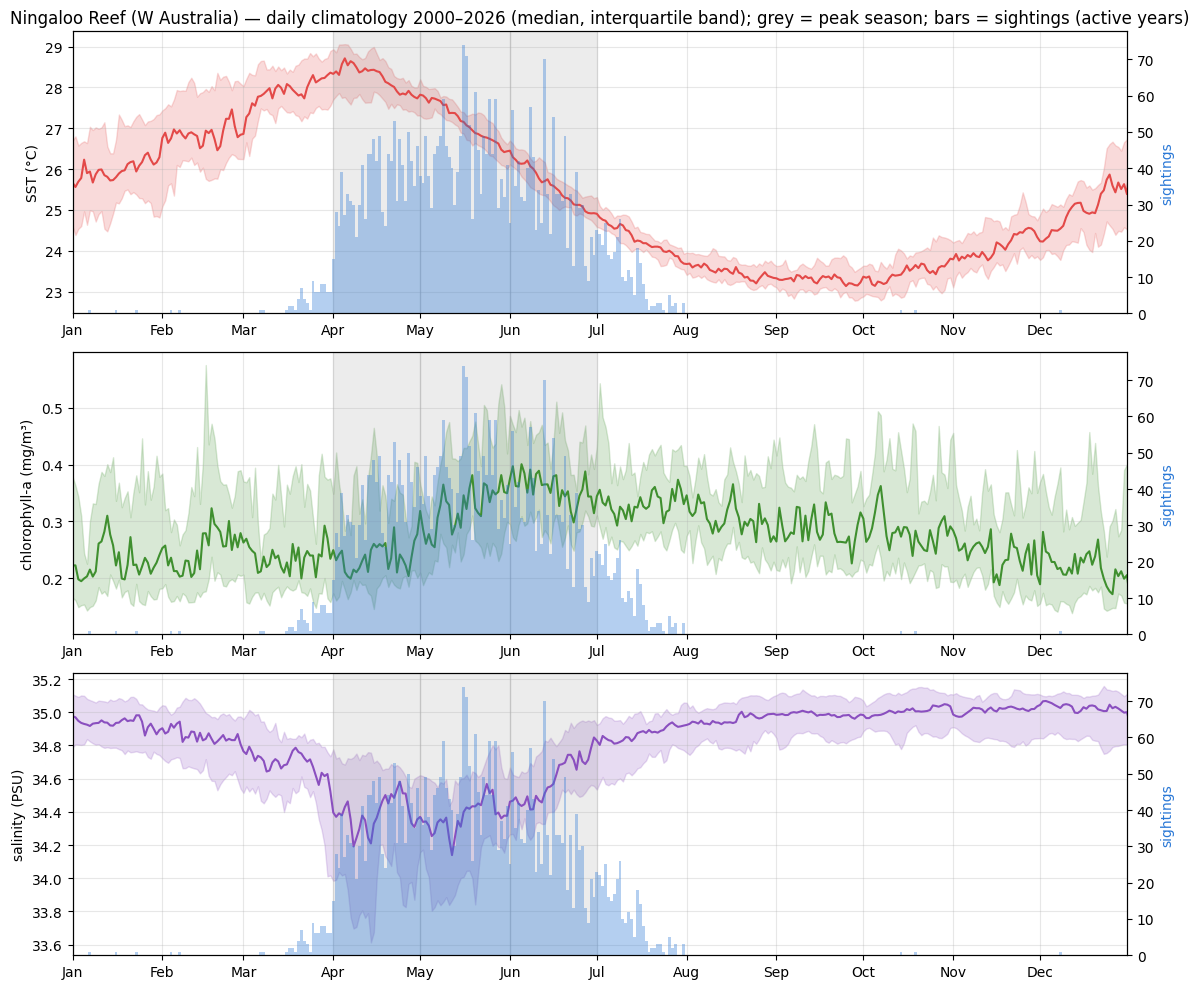

In [19]:
climatology(SITES[0])

*Reading:*

#### Response curves — SST

*Reading:*

#### Response curves — chlorophyll-a

*Reading:*

#### Response curves — salinity

*Reading:*

#### Anomaly response curves

*Reading:*

#### Lagged chlorophyll

*Reading:*

#### Year by year

*Reading:*

### 4.2 Philippines — February to May

#### Context (climatology)

*Reading:*

#### Response curves — SST

*Reading:*

#### Response curves — chlorophyll-a

*Reading:*

#### Response curves — salinity

*Reading:*

#### Anomaly response curves

*Reading:*

#### Lagged chlorophyll

*Reading:*

#### Year by year

*Reading:*

### 4.3 Gulf of Mexico / Caribbean — June to August

#### Context (climatology)

*Reading:*

#### Response curves — SST

*Reading:*

#### Response curves — chlorophyll-a

*Reading:*

#### Response curves — salinity

*Reading:*

#### Anomaly response curves

*Reading:*

#### Lagged chlorophyll

*Reading:*

#### Year by year

*Reading:*

## Step 5 — Comparison of the three sites

### 5.1 Summary table: site × variable → shape of the response curve, holds with anomalies?, useful lag?

### 5.2 Conclusions

